In [31]:
import sqlite3
import pandas as pd
import numpy as np
import matplotlib
import matplotlib.pyplot as plt
from scipy.stats import pearsonr
from sklearn.linear_model import LinearRegression
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.model_selection import train_test_split

In [32]:
from styleplot import style_plot

In [28]:
def download():
    from urllib.request import urlretrieve
    from pathlib import Path

    url = (
        "https://raw.githubusercontent.com/Explore-AI/Public-Data/master/"
        "Maji_Ndogo/Maji_Ndogo_farm_survey_small.db"
    )

    db_file = Path("Maji_Ndogo_farm_survey_small.db")

    if not db_file.exists():
        urlretrieve(url, db_file)
        print(f"Downloaded '{db_file}'.")
    else:
        print(f"'{db_file}' already exists.")

    return
    

In [30]:
download()

'Maji_Ndogo_farm_survey_small.db' already exists.


In [33]:
def _():
    ### DO NOT CHANGE ANYTHING IN THIS CELL, ONLY EXECUTE IT!
    import sqlite3
    # Load the Maji Ndogo farm survey from the SQLite database
    conn = sqlite3.connect("Maji_Ndogo_farm_survey_small.db")
    sql_query = """
    SELECT *
    FROM geographic_features
    LEFT JOIN weather_features USING (Field_ID)
    LEFT JOIN soil_and_crop_features USING (Field_ID)
    LEFT JOIN farm_management_features USING (Field_ID)
    """
    df = pd.read_sql_query(sql_query, conn)
    conn.close() 

    # Fix swapped column names
    df.rename(
        columns={
            "Annual_yield": "Crop_type_Temp",
            "Crop_type": "Annual_yield"
        },
        inplace=True
    )

    df.rename(
        columns={
            "Crop_type_Temp": "Crop_type"
        },
        inplace=True
    )

    # Fix elevation
    df["Elevation"] = df["Elevation"].abs()

    # Fix crop spelling
    corrections = {
        "cassaval": "cassava",
        "wheatn": "wheat",
        "teaa": "tea"
    }

    df["Crop_type"] = df["Crop_type"].apply(
        lambda c: corrections.get(c.strip(), c.strip())
    )

    df = df.dropna()

    print(f"Shape: {df.shape}")
    print(
        df[
            ["Rainfall", "Ave_temps", "Standard_yield"]
        ].head()
    )

    return (df,)

In [34]:
conn = sqlite3.connect("Maji_Ndogo_farm_survey_small.db")
tables = pd.read_sql_query(
    """
    SELECT name
    FROM sqlite_master
    WHERE type='table'
    ORDER BY name
    """,
    conn
)
conn.close()
tables

,name
0,farm_management_features
1,geographic_features
2,soil_and_crop_features
3,weather_features


In [35]:
result = _()
df = result[0]

Shape: (5654, 18)
   Rainfall  Ave_temps  Standard_yield
0    1125.2      15.00        0.577964
1    1450.7      13.35        0.486302
2    2208.9      13.30        0.649647
3     328.8      13.20        0.532348
4     785.2      14.25        0.555076


In [36]:
df.head()

,Field_ID,Elevation,Latitude,Longitude,Location,Slope,Rainfall,Min_temperature_C,Max_temperature_C,Ave_temps,Soil_fertility,Soil_type,pH,Pollution_level,Plot_size,Annual_yield,Crop_type,Standard_yield
0,40734,786.05580,-7.389911,-7.556202,Rural_Akatsi,14.795113,1125.2,-3.1,33.1,15.00,0.62,Sandy,6.169393,0.085267,1.3,0.751354,cassava,0.577964
1,30629,674.33410,-7.736849,-1.051539,Rural_Sokoto,11.374611,1450.7,-3.9,30.6,13.35,0.64,Volcanic,5.676648,0.399684,2.2,1.069865,cassava,0.486302
2,39924,826.53390,-9.926616,0.115156,Rural_Sokoto,11.339692,2208.9,-1.8,28.4,13.30,0.69,Volcanic,5.331993,0.358029,3.4,2.208801,tea,0.649647
3,5754,574.94617,-2.420131,-6.592215,Rural_Kilimani,7.109855,328.8,-5.8,32.2,13.20,0.54,Loamy,5.328150,0.286687,2.4,1.277635,cassava,0.532348
4,14146,886.35300,-3.055434,-7.952609,Rural_Kilimani,55.007656,785.2,-2.5,31.0,14.25,0.72,Sandy,5.721234,0.043190,1.5,0.832614,wheat,0.555076


In [56]:
#df.to_csv("ndogo_farm_data.csv", index=False)

### __Challenge 1: Visualizing the Relationship__

Every predictive model starts with a question: *Is there even a relationship to model?*

Before fitting any line, we need to look at the data. We have many features, but let's begin with `Ave_temps` — average temperature across the field's growing season. Temperature directly affects crop growth rates, photosynthesis efficiency, and evapotranspiration. It's a logical first candidate.

### __Task__
 Create a function named `temp_yield_correlation` that:
- Takes a DataFrame and the names of the temperature column and the yield column as parameters.
- Generates a scatter plot visualizing the relationship between the two variables, with axis labels and a title.
- Calculates the Pearson correlation coefficient between them.
- Returns the Pearson correlation coefficient as a float.

**Note:**
- Use `matplotlib` for plotting.
- Use `scipy.stats.pearsonr` or `numpy.corrcoef` for the correlation coefficient.
- Ensure your function returns the Pearson correlation coefficient as a float.

### __Expected Output__
```
Correlation: 0.006785950289020154
```

In [37]:
def temp_yield_correlation(df, temp_col, yield_col):
    """
    Plot the relationship between temperature and crop yield
    and calculate the Pearson correlation coefficient.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing the temperature and yield columns.
    temp_column : str
        Name of the temperature column.
    yield_column : str
        Name of the yield column.

    Returns
    -------
    float
        Pearson correlation coefficient.
    """
    correlation, _  = pearsonr(df[temp_col], df[yield_col])

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(
        df[temp_col], 
        df[yield_col], 
        alpha=0.5,
        color = "#347989"
    )

    # Add labels and title
    style_plot(
        ax,
        title = "Relationship Between Average Temperature and Crop Yield",
        xlabel = "Average Temperature (°C)",
        ylabel = "Standard Yield",
        grid = True
    )

    # Display plot
    plt.tight_layout()
    plt.show()

    return float(correlation)

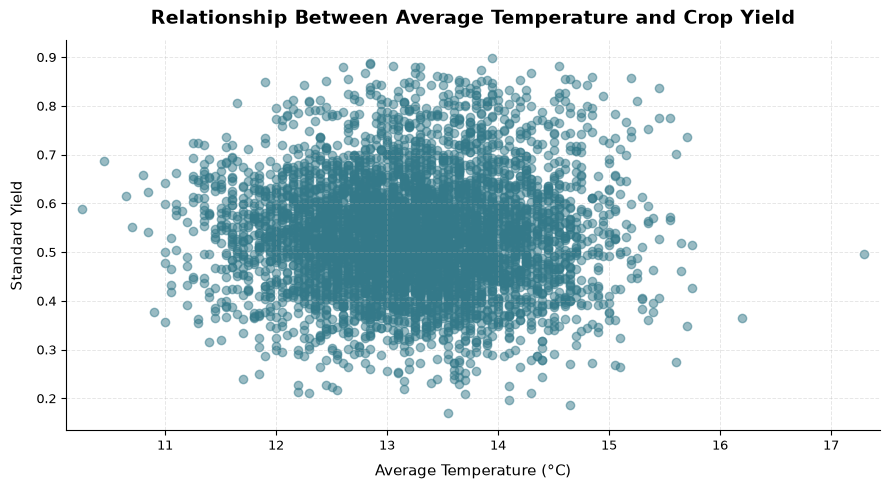

Correlation: 0.006785950289020187


In [40]:
# Get both returned values separately
correlation = temp_yield_correlation(
    df,
    "Ave_temps",
    "Standard_yield"
)

# Use them independently
print(f"Correlation: {correlation}")

### __Challenge 2: Rainfall as a Predictor__

Let's shift focus to `Rainfall`. Annual rainfall is one of the most cited drivers of agricultural yield — too little and crops wither, too much and roots drown. If any single feature should predict yield, rainfall is the best candidate in this dataset.

### __Task__
 Create a function named `rainfall_yield_relationship` that:
- Takes a DataFrame and the names of the rainfall column and the yield column as parameters.
- Generates a scatter plot visualizing the relationship and overlays the fitted regression line.
- Fits a simple linear regression model using scikit-learn's `LinearRegression`.
- Returns the slope and intercept of the fitted model as a tuple `(slope, intercept)`.

**Note:**
- Use `matplotlib` for plotting.
- Use `sklearn.linear_model.LinearRegression` for modeling.
- Plot the regression line in red on top of the scatter plot.

### __Expected Output__
```
Slope: 8.77309700148857e-06
Intercept: 0.5238603528299144
```

In [45]:
def rainfall_yield_relationship(df, rainfall_col, yield_col):
    """
    Visualize the relationship between rainfall and yield
    and fit a simple linear regression model.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing rainfall and yield data.
    rainfall_col : str
        Name of the rainfall column.
    yield_col : str
        Name of the yield column.

    Returns
    -------
    tuple
        Slope and intercept of the fitted regression model.
    """

    X = df[[rainfall_col]]
    y = df[yield_col]

    # Create and fit the linear regression model
    lr = LinearRegression()
    lr.fit(X, y)

    # Generate predicted yield values
    y_pred = lr.predict(X)

    # Create scatter plot
    fig, ax = plt.subplots(figsize=(9, 5))
    ax.scatter(
        df[rainfall_col],
        df[yield_col],
        alpha=0.5,
        color = "#347989"
    )

    # Plot regression line
    plt.plot(
        df[rainfall_col],
        y_pred,
        color="crimson",
        linewidth=2
    )
    
    # Add labels and title
    style_plot(
        ax,
        title = "Relationship Between Rainfall and Crop Yield",
        xlabel = "Rainfall (mm)",
        ylabel = "Standard Yield",
        grid = True
    )

    # Display plot
    plt.tight_layout()
    plt.show()

    # Extract slope and intercept
    slope = lr.coef_[0]
    intercept = lr.intercept_

    return float(slope), float(intercept)

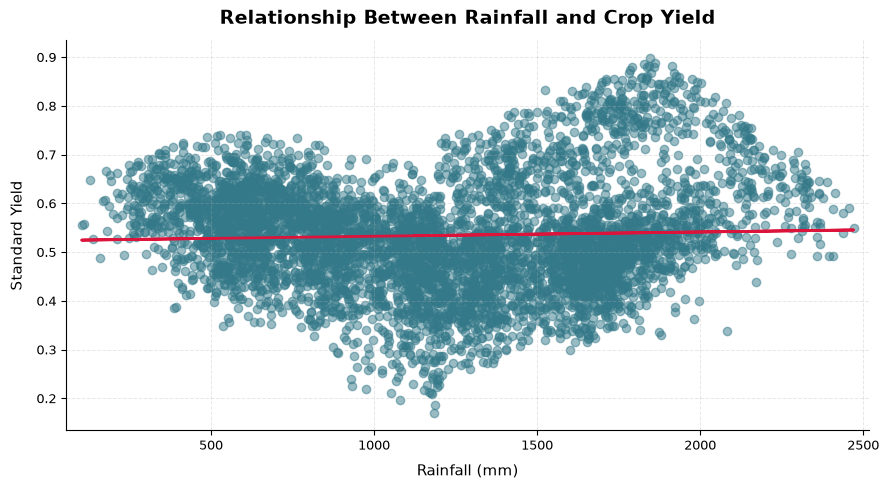

Slope: 0.00000877
Intercept: 0.5239


In [46]:
slope, intercept = rainfall_yield_relationship(
    df,
    "Rainfall",
    "Standard_yield"
)

print(f"Slope: {slope:.8f}")
print(f"Intercept: {intercept:.4f}")

### __Challenge 3: Evaluating Rainfall's Predictive Power__

A regression line can always be drawn through data. The question is whether that line is *useful*. Let's measure how well rainfall predicts yield using four performance metrics:

- **R-squared (R²)**: The proportion of variance in yield explained by rainfall. Ranges from 0 (no explanatory power) to 1 (perfect).
- **MAE**: Mean Absolute Error — average magnitude of prediction errors, in the same units as yield.
- **MSE**: Mean Squared Error — penalizes large errors more heavily than MAE.
- **RMSE**: Root Mean Squared Error — the square root of MSE, in the same units as yield.

### __Task__
 Create a function named `evaluate_rainfall_model` that:
- Takes a DataFrame as input.
- Trains a simple linear regression model using `Rainfall` as the predictor and `Standard_yield` as the target, on the **entire dataset**.
- Calculates R-squared, MAE, MSE, and RMSE.
- Returns a tuple `(r2, mae, mse, rmse)`.

### __Expected Output__
```
Evaluation Metrics:
R-squared: 0.0015379401175150686
MAE: 0.08766959364573583
MSE: 0.012479116464950486
RMSE: 0.11170996582646728
```

In [47]:
def evaluate_rainfall_model(df):
    """
    Train a linear regression model using Rainfall
    to predict Standard_yield and evaluate its performance.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing Rainfall and Standard_yield.

    Returns
    -------
    tuple
        R-squared, MAE, MSE, and RMSE.
    """

    # Define predictor and target
    X = df[["Rainfall"]]
    y = df["Standard_yield"]

    # Train the model on the entire dataset
    lr = LinearRegression()
    lr.fit(X, y)

    # Generate predictions
    y_pred = lr.predict(X)

    # Calculate evaluation metrics
    r2 = r2_score(y, y_pred)
    mae = mean_absolute_error(y, y_pred)
    mse = mean_squared_error(y, y_pred)
    rmse = np.sqrt(mse)

    return float(r2), float(mae), float(mse), float(rmse)

In [48]:
r2, mae, mse, rmse = evaluate_rainfall_model(df)

print("Evaluation Metrics:")
print(f"R-squared: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

Evaluation Metrics:
R-squared: 0.0015379401175148466
MAE: 0.08766959364573582
MSE: 0.012479116464950488
RMSE: 0.11170996582646728


### __Challenge 4: The Train-Test Split__

So far we have trained and evaluated our model on the same data. That is like a teacher grading students on the questions they practiced — it tells us how well the model memorized the training data, not how well it will predict yields for fields it has never seen.

The **train-test split** fixes this. We hold out a random 20% of the data, train on the remaining 80%, and evaluate only on the held-out set. If performance is similar to the full-data evaluation, our model is generalizing — not just memorizing.

### __Task__
Create a function named `train_test_split_evaluate` that:
- Takes in the DataFrame.
- Separates it into features (`X`) using `Rainfall` and target (`y`) using `Standard_yield`.
- Splits the data into training and testing sets using `test_size=0.2` and `random_state=42`.
- Trains a simple linear regression model on the training set.
- Evaluates the model on the test set, calculating R-squared, MAE, MSE, and RMSE.
- Returns `(r2, mae, mse, rmse), (predictions, y_test)`.

**Note:** The second tuple `(predictions, y_test)` will be used in Challenge 5.

### __Expected Output__
```
Evaluation Metrics on Test Set:
R-squared: 4.80629092007856e-05
MAE: 0.08998991387920033
MSE: 0.01332478573926128
RMSE: 0.11543303573614132
```

In [50]:
def train_test_split_evaluate(df):
    """
    Split the data into training and testing sets,
    train a linear regression model, and evaluate it
    on the test set.

    Parameters
    ----------
    df : pandas.DataFrame
        Dataset containing Rainfall and Standard_yield.

    Returns
    -------
    tuple
        ((r2, mae, mse, rmse), (predictions, y_test))
    """

     # Define feature and target
    X = df[["Rainfall"]]
    y = df["Standard_yield"]

    # Split into training and testing sets
    X_train, X_test, y_train, y_test = train_test_split(
        X,
        y,
        test_size=0.2,
        random_state=42
    )

    # Create and train the model
    lr = LinearRegression()
    lr.fit(X_train, y_train)

    # Make predictions on the test set
    y_pred = lr.predict(X_test)

    # Calculate evaluation metrics
    r2 = r2_score(y_test, y_pred)
    mae = mean_absolute_error(y_test, y_pred)
    mse = mean_squared_error(y_test, y_pred)
    rmse = np.sqrt(mse)

    return (
        (float(r2), float(mae), float(mse), float(rmse)),
        (y_pred, y_test)
    )

In [51]:
metrics, prediction_data = train_test_split_evaluate(df)

r2, mae, mse, rmse = metrics
predictions, y_test = prediction_data

print("Evaluation Metrics on Test Set:")
print(f"R-squared: {r2}")
print(f"MAE: {mae}")
print(f"MSE: {mse}")
print(f"RMSE: {rmse}")

Evaluation Metrics on Test Set:
R-squared: 4.8062909200674575e-05
MAE: 0.08998991387920033
MSE: 0.013324785739261281
RMSE: 0.11543303573614133


## __Challenge 5: Diagnosing Model Fit Through Residual Analysis__

Our metrics give us a high-level picture. Residual analysis gives us the X-ray. **Residuals** are the differences between actual yield values and our model's predictions:

```
residual = actual_yield - predicted_yield
```

A well-specified linear regression model should produce residuals that:
1. Are **roughly normally distributed** — a bell curve centered near zero.
2. Have a **mean close to zero** — meaning the model is not systematically over- or under-predicting.
3. Do not fan out or curve — no systematic pattern suggesting a non-linear relationship.

### __Task__
Create a function named `analyze_model_residuals` that:
- Uses `predictions` and `y_test` from Challenge 4 to calculate residuals (`y_test - predictions`).
- Plots the residuals as a histogram with a vertical line at zero, axis labels, and a title.
- Calculates the mean and standard deviation of the residuals.
- Returns `(mean_residual, std_residual)`.

### __Expected Output__
```
Mean residual: 0.007188033196518129
Std of residuals: 0.11520901838843622
```


In [54]:
def analyze_model_residuals(predictions, y_test):
    """
    Calculate and visualize model residuals.

    Parameters
    ----------
    predictions : array-like
        Predicted yield values from the regression model.
    y_test : array-like
        Actual yield values from the test set.

    Returns
    -------
    tuple
        Mean and standard deviation of the residuals.
    """

    residuals = y_test - predictions
    
    # Calculate mean and standard deviation
    mean_residual = np.mean(residuals)
    std_residual = np.std(residuals)

    # Plot residual distribution
    fig, ax = plt.subplots(figsize=(8, 4))
    plt.hist(residuals, bins=30, alpha=0.7, color = "#347989")

    # Add vertical line at zero
    plt.axvline(
        x=0,
        linestyle="--",
        color='crimson',
        linewidth=2
    )

    # Add labels and title
    style_plot(
        ax,
        title = "Distribution of Model Residuals",
        xlabel = "Residual",
        ylabel = "Frequency",
        grid = True
    )

    # Display plot
    plt.tight_layout()
    plt.show()

    return float(mean_residual), float(std_residual)

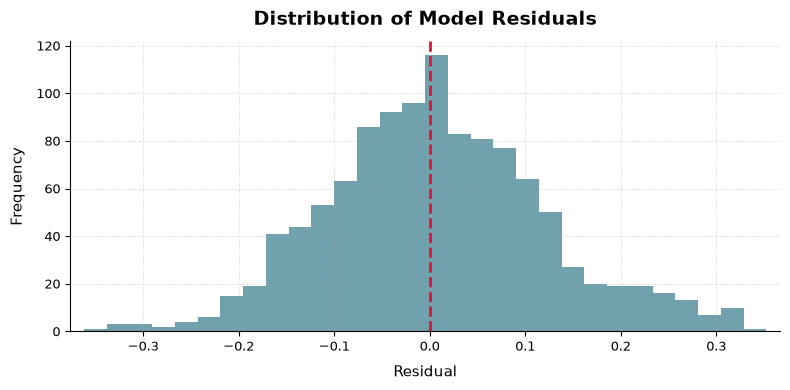

Mean residual: 0.007188033196518124
Std of residuals: 0.11520901838843622


In [55]:
mean_residual, std_residual = analyze_model_residuals(
    predictions,
    y_test
)

print(f"Mean residual: {mean_residual}")
print(f"Std of residuals: {std_residual}")